# **AIR QUALITY INDEX PREDICTION USING MACHINE LEARNING:**
The Air Quality Index (AQI) is a numerical scale used to measure and communicate the quality of air in a particular location. It indicates how polluted the air currently is or how polluted it is expected to become. The AQI value is calculated based on the concentration of various pollutants such as particulate matter, carbon monoxide, nitrogen dioxide, and sulfur dioxide.

Poor air quality can have serious impacts on human health, including respiratory diseases, heart problems, and other long-term health issues. Therefore, monitoring and predicting air quality is important for environmental protection and public health.

Machine learning techniques can help analyze historical air quality data and predict future air pollution levels.

**PROBLEM STATEMENT:**

Air pollution has become a major environmental issue worldwide. Monitoring air quality continuously is essential to protect human health and the environment. However, predicting air pollution levels manually is difficult due to the presence of multiple influencing factors.

The objective of this project is to develop a machine learning model that predicts the average pollutant value based on pollutant characteristics and geographical location.

**OBJECTIVES OF THE PROJECT:**

The main objectives of this project are:

1. To analyze air quality data using exploratory data analysis.
2. To preprocess the dataset for machine learning.
3. To train a predictive model using machine learning algorithms.
4. To evaluate the performance of the trained model.
5. To predict pollutant levels using the trained model.

**DATASET DESCRIPTION:**

 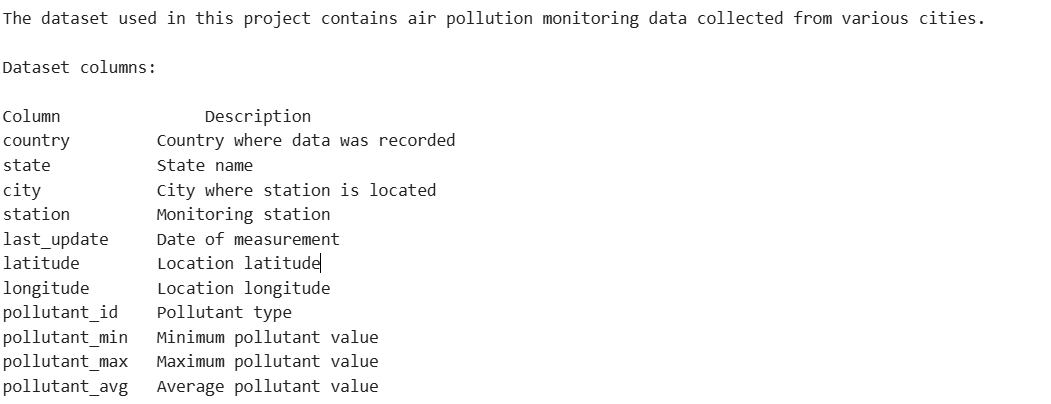

**TOOLS AND TECHNOLOGIES USED:**

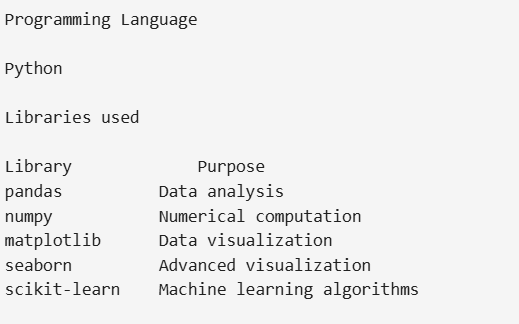

In [ ]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#These libraries help in data analysis, visualization, and machine learning operations.

In [ ]:
#Load the Dataset
df = pd.read_csv("AQI.csv")
df.head()

#The dataset is loaded using pandas and the first five rows are displayed.

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00:00,16.554731,80.649110,SO2,20.0,23.0,21.0
1,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00:00,16.554731,80.649110,OZONE,17.0,35.0,22.0
2,India,Andhra_Pradesh,Visakhapatnam,"GVM Corporation, Visakhapatnam - APPCB",19-05-2025 10:00:00,17.720000,83.300000,PM10,23.0,66.0,36.0
3,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00:00,27.103358,93.679645,NO2,4.0,5.0,5.0
4,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00:00,27.103358,93.679645,CO,10.0,19.0,12.0


In [ ]:
#Dataset Information
df.info()

#This shows:

    #1. number of rows and columns
    #2. datatype of each column
    #3. missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3077 entries, 0 to 3076
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3077 non-null   object 
 1   state          3077 non-null   object 
 2   city           3077 non-null   object 
 3   station        3077 non-null   object 
 4   last_update    3077 non-null   object 
 5   latitude       3077 non-null   float64
 6   longitude      3077 non-null   float64
 7   pollutant_id   3077 non-null   object 
 8   pollutant_min  2778 non-null   float64
 9   pollutant_max  2778 non-null   float64
 10  pollutant_avg  2778 non-null   float64
dtypes: float64(5), object(6)
memory usage: 264.6+ KB


In [ ]:
#Statistical Summary
df.describe()

#This provides statistical information such as mean, standard deviation, minimum, and maximum values.

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3077.000000,3077.000000,2778.000000,2778.000000,2778.000000
mean,22.250067,78.682006,21.670986,59.251620,33.933765
std,5.519664,4.854371,25.535470,65.896529,36.125555
min,8.514909,70.909168,1.000000,1.000000,1.000000
25%,19.036458,75.521300,5.000000,15.000000,9.000000
50%,23.023389,77.508730,13.000000,40.000000,23.000000
75%,26.833997,80.723178,29.000000,79.000000,45.000000
max,34.066206,94.636574,303.000000,500.000000,336.000000


In [ ]:
#Checking Missing Values OR DATA CLENING
df.isnull().sum()

#This identifies missing values present in each column.

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
pollutant_min,299
pollutant_max,299


In [ ]:
#filling the missing values
df.fillna({
    'pollutant_min': df['pollutant_min'].median(),
    'pollutant_max': df['pollutant_max'].median(),
    'pollutant_avg': df['pollutant_avg'].median()
}, inplace=True)

#The dataset contained missing values in the columns pollutant_min, pollutant_max, and pollutant_avg. These missing values were handled using median imputation. The median value of each column was calculated and used to replace missing entries. Median was chosen instead of mean because pollution data may contain outliers. This preprocessing step ensured that the dataset became complete and suitable for machine learning model training.

In [ ]:
#after filling the missing values then chack the missing values
df.isnull().sum()

,0
country,0
state,0
city,0
station,0
last_update,0
latitude,0
longitude,0
pollutant_id,0
pollutant_min,0
pollutant_max,0


In [ ]:
#Exploratory Data Analysis (EDA)
df['pollutant_id'].value_counts()

,count
pollutant_id,
PM2.5,456
PM10,454
NO2,449
CO,442
SO2,438
OZONE,432
NH3,406


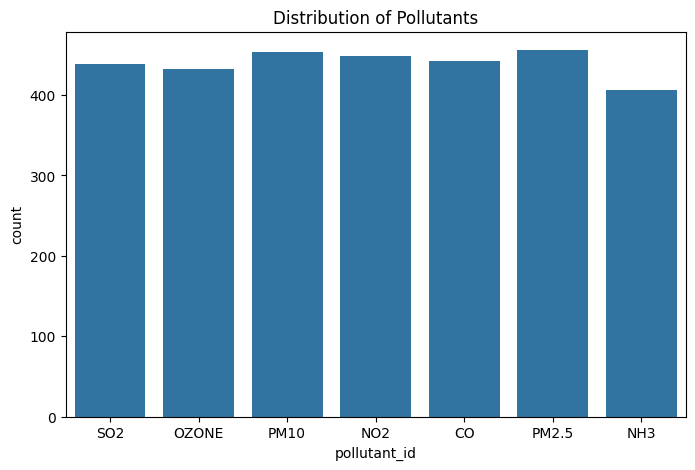

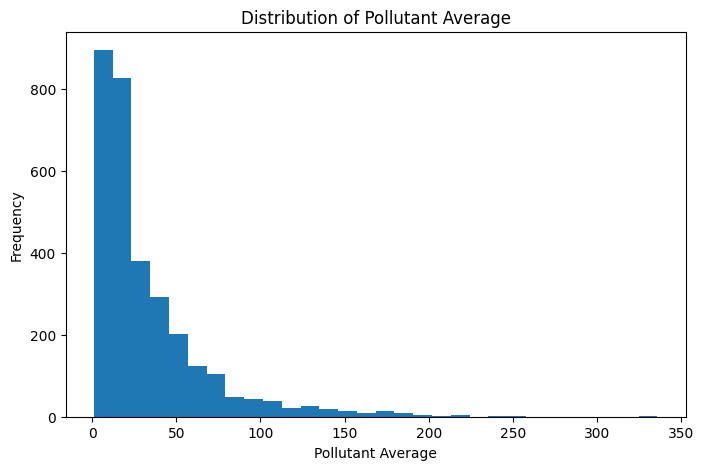

In [ ]:
#Pollutant Distribution Graph

#EDA helps in understanding the dataset through visualization.
plt.figure(figsize=(8,5))
sns.countplot(x='pollutant_id', data=df)
plt.title("Distribution of Pollutants")
plt.show()
#This graph shows how frequently different pollutants appear in the dataset.



# Histogram of Pollutant Average

plt.figure(figsize=(8,5))
plt.hist(df['pollutant_avg'], bins=30)
plt.title("Distribution of Pollutant Average")
plt.xlabel("Pollutant Average")
plt.ylabel("Frequency")
plt.show()
#Shows the distribution of pollution levels.

In [ ]:
# Data Preprocessing
    #Machine learning models cannot work with text data.
    #So we convert categorical variables into numbers.
    #Using **scikit-learn LabelEncoder.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['city'] = le.fit_transform(df['city'])
df['state'] = le.fit_transform(df['state'])
df['pollutant_id'] = le.fit_transform(df['pollutant_id'])

In [ ]:
#Feature Selection
#Select input features and target variable.
X = df[['city','state','latitude','longitude','pollutant_id',
        'pollutant_min','pollutant_max']]

y = df['pollutant_avg']

    #X ---->>> Independent variables
    #y ---->>> Target variable

In [ ]:
#Train Test Split
#Split dataset into training and testing data.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Model Training
    #Use Linear Regression.
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

#The model learns patterns from training data.

LinearRegression()

In [ ]:
#Model Prediction
y_pred = model.predict(X_test)
print(y_pred)

#Predicts pollution values for test data.

[ 21.08088328  14.22856682  33.11316275  20.48752095  18.52897548
  50.26913158  82.38639382  37.18389923  71.07430469   4.98857534
   8.97100229 119.91823469   8.23622372  22.2538519   10.53357245
  49.67528395  15.87432311  37.94190011  77.97236154   8.50743619
  29.38958817   7.5035005   55.40385227  22.40710833  21.49662005
   3.17378987  23.10994431  71.37284311  96.62187756   1.28628912
  11.77471815  39.801575    38.19714181  20.44163334  37.91279637
  10.57258012  53.52880877  24.86903257  10.03760562   7.94329309
   5.25540741   1.58862885  15.55236708  20.51187672  58.38329307
  35.43943887 123.90675239  42.52139791  18.6845886   12.13190366
  44.35159631   9.87808456   6.60285124   5.63572494   3.53645764
  14.12387176  19.98547156  30.92609952  71.83322122  29.85698981
  32.40915616  16.3712187    2.14386574   4.6938161   57.48377352
  47.43751188  81.30798576  36.00229983   9.18539931 129.18865913
  10.90807368 119.45319266  16.42643328  20.58655368  20.90404155
  25.65891

In [ ]:
#Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae) # Average  (Average prediction error)
print("MSE:", mse) #Squared error (Squared error)
print("RMSE:", rmse) #Standard error (Root mean square error)
print("R2 Score:", r2) #Model accuracy

MAE: 5.5384640206141915
MSE: 116.00380110196716
RMSE: 10.77050607455226
R2 Score: 0.9101509821737942


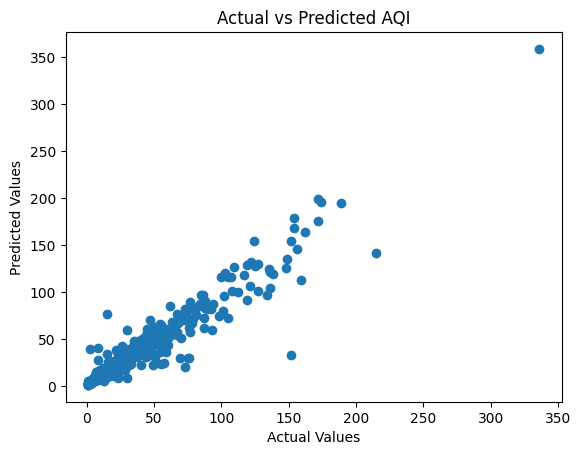

In [ ]:
#Prediction Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted AQI")
plt.show()